# Import etc

In [1]:
import cupy as cp

# Clear memory pool cache
cp.get_default_memory_pool().free_all_blocks()

# Also clear pinned memory if used
cp.get_default_pinned_memory_pool().free_all_blocks()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI

import os
import sys

# Changing directory for VSCode notebook
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglikebasic
import modeselector
import parismc
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 0.25     # Total time

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.


In [3]:
traj = EMRIInspiral(**inspiral_kwargs)
amp = AmpInterpKerrEccEq(**amplitude_kwargs) 
interpolate_mode_sum = InterpolatedModeSum(**sum_kwargs)
ylm_gen = GetYlms(**Ylm_kwargs)
gwf = GWfuncs.GravWaveAnalysis(T=T, dt=dt)


In [4]:
# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5

data = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)

data_f = gwf.freq_wave(data)
snr_data = gwf.SNR(data_f)
print(f"SNR of data: {snr_data}")

SNR of data: 107.43944631400305


In [5]:
# Taken from view cuz its a internal function
# TODO:  maybe add to GWFuncs?
def get_viewing_angles(qS, phiS, qK, phiK):
    """Transform from the detector frame to the source  frame"""
    cqS = np.cos(qS)
    sqS = np.sin(qS)
    cphiS = np.cos(phiS)
    sphiS = np.sin(phiS)
    cqK = np.cos(qK)
    sqK = np.sin(qK)
    cphiK = np.cos(phiK)
    sphiK = np.sin(phiK)
    # sky location vector
    R = np.array([sqS * cphiS, sqS * sphiS, cqS])
    # spin vector
    S = np.array([sqK * cphiK, sqK * sphiK, cqK])
    # get viewing angles
    phi = -np.pi / 2.0  # by definition of source frame
    theta = np.arccos(-np.dot(R, S))  # normalized vector

    return (theta, phi)

theta, phi = get_viewing_angles(qS, phiS, qK, phiK)
theta, phi


(2.3129424767905524, -1.5707963267948966)

# Fiddling around with $\Delta T$

In [6]:
# Num of traj points
# NOTE: fiddle here
N_traj = int(5e3)
# Time steps
delta_T = T * YRSID_SI / N_traj
delta_T

1577.9074881772797

In [7]:
# Getting the trajectory etc
(t, p, e, x, Phi_phi, Phi_theta, Phi_r) = traj(
    m1, m2, a, p0, e0, xI0, T=T, dt=delta_T, 
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, 
    upsample=True)
teuk_modes = amp(a, p, e, x)
ylms = ylm_gen(amp.unique_l, amp.unique_m, theta, phi).copy()[amp.inverse_lm]


In [8]:
from few.utils.geodesic import get_fundamental_frequencies

# Getting fundamental frequencies
OmegaPhi, _, OmegaR = get_fundamental_frequencies(a, p, e, x)

gw_frequencies_per_mode = []
for idx in range(len(amp.l_arr)):
    m = amp.m_arr[idx]
    n = amp.n_arr[idx]

    m = m.get() if isinstance(m, cp.ndarray) else m
    n = n.get() if isinstance(n, cp.ndarray) else n

    # Calculate GW frequencies
    f_gw = m * OmegaPhi + n * OmegaR
    gw_frequencies_per_mode.append(f_gw)



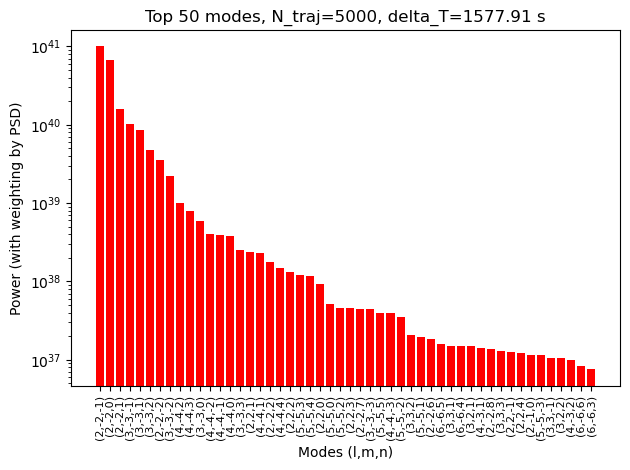

In [9]:
# Get WEIGHTED power
m0mask = amp.m_arr_no_mask != 0
total_power = gwf.calc_power(teuk_modes, ylms, m0mask, m1=m1, m2=m2, gw_freqs=gw_frequencies_per_mode)

# Get mode labels
mode_labels = [f"({l},{m},{n})" for l,m,n in zip(amp.l_arr, amp.m_arr, amp.n_arr)]

# Bar plot of modes vs approx inner product for top M modes 
M_mode = 50
ma = list(zip(mode_labels, total_power)) 
# Sort by power and pick top 100 modes
ma_sorted = sorted(ma, key=lambda x: x[1], reverse=True)[:M_mode]
ma_modes = [x[0] for x in ma_sorted]
ma_power = [x[1].get() for x in ma_sorted]

plt.bar(range(len(ma_power)), ma_power, color='red')
plt.xticks(range(len(ma_modes)), ma_modes, rotation=90, fontsize=8)
plt.xlabel('Modes (l,m,n)')
plt.ylabel('Power (with weighting by PSD)')
plt.title(f'Top {M_mode} modes, N_traj={N_traj}, delta_T={delta_T:.2f} s')
plt.yscale('log')
plt.tight_layout()
plt.show()

In [10]:
ma_modes[:5]

['(2,-2,-1)', '(2,-2,0)', '(2,-2,1)', '(3,-3,-1)', '(3,-3,1)']

In [11]:
# sorry im too lazy to convert from string to tuple
sel_modes = [(2,-2,-1), (2,-2,0), (2,-2,1), (3, -3, -1), (3, -3, 1)]

In [12]:
sum_kwargs_sep = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True,
    "separate_modes": True
}
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)

In [13]:
sorted_indices = sorted(range(len(sel_modes)), 
                       key=lambda i: (amp.index_map[sel_modes[i]] % 1000 // 100, 
                                      -(amp.index_map[sel_modes[i]] % 100)))


In [14]:
sorted_indices

[2, 1, 0, 4, 3]

In [15]:
waveform_per_mode = waveform_gen_sep(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
                                     mode_selection=sel_modes, include_minus_mkn=False)

In [16]:

waveform_0 = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
                                     mode_selection=[sel_modes[0]], include_minus_mkn=False)

waveform_1 = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
                                     mode_selection=[sel_modes[1]], include_minus_mkn=False)

waveform_2 = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
                                     mode_selection=[sel_modes[2]], include_minus_mkn=False)

waveform_3 = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
                                     mode_selection=[sel_modes[3]], include_minus_mkn=False)

waveform_4 = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
                                     mode_selection=[sel_modes[4]], include_minus_mkn=False)

In [17]:
waveform_4

array([ 5.71581946e-23+6.50326787e-23j,  4.42538173e-23+7.44171995e-23j,
        2.98464494e-23+8.12743552e-23j, ...,
       -9.37258724e-23-1.63202938e-22j, -2.81516570e-23-1.86084239e-22j,
        4.12566671e-23-1.83624260e-22j])

In [18]:
waveform_per_mode[:,3]

array([ 5.71581946e-23+6.50326787e-23j,  4.42538173e-23+7.44171995e-23j,
        2.98464494e-23+8.12743552e-23j, ...,
       -9.37258724e-23-1.63202938e-22j, -2.81516570e-23-1.86084239e-22j,
        4.12566671e-23-1.83624260e-22j])

Waveforms are ordered in reverse from thousands then hundredths

in this case: 2,1,0,4,3

In [19]:
waveform_per_mode_sorted = waveform_per_mode[:,sorted_indices]

In [20]:
waveform_per_mode_sorted[:,0]

array([ 1.11859302e-22+4.40759826e-22j,  1.72970305e-23+4.54403736e-22j,
       -7.80289436e-23+4.47988439e-22j, ...,
       -6.20138372e-22+3.35810435e-22j, -7.00249794e-22+8.36137114e-23j,
       -6.81772374e-22-1.80355853e-22j])

In [21]:
waveform_0

array([ 1.11859302e-22+4.40759826e-22j,  1.72970305e-23+4.54403736e-22j,
       -7.80289436e-23+4.47988439e-22j, ...,
       -6.20138372e-22+3.35810435e-22j, -7.00249794e-22+8.36137114e-23j,
       -6.81772374e-22-1.80355853e-22j])

In [22]:
# SNR per mode
hf_0 = gwf.freq_wave(waveform_0)
snr_0 = gwf.SNR(hf_0)
print(f"SNR of mode {sel_modes[0]}: {snr_0}")

hf_1 = gwf.freq_wave(waveform_1)
snr_1 = gwf.SNR(hf_1)
print(f"SNR of mode {sel_modes[1]}: {snr_1}")

hf_2 = gwf.freq_wave(waveform_2)
snr_2 = gwf.SNR(hf_2)
print(f"SNR of mode {sel_modes[2]}: {snr_2}")

hf_3 = gwf.freq_wave(waveform_3)
snr_3 = gwf.SNR(hf_3)
print(f"SNR of mode {sel_modes[3]}: {snr_3}")

hf_4 = gwf.freq_wave(waveform_4)
snr_4 = gwf.SNR(hf_4)
print(f"SNR of mode {sel_modes[4]}: {snr_4}")

SNR of mode (2, -2, -1): 66.05913408664554
SNR of mode (2, -2, 0): 41.579233124363256
SNR of mode (2, -2, 1): 15.223406419157653
SNR of mode (3, -3, -1): 16.765666268581867
SNR of mode (3, -3, 1): 14.07108444911397


In [29]:
params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)

loglike_obj = loglikebasic.LogLike(params_star, waveform_gen, gwf, M_init=5, verbose=True, waveform_gen_sep=waveform_gen_sep, noise_weighted=True)


Delta_T for mode selection: 1577.9074881772797 seconds
Generating modes at initialization...
Initial mode selected: (2, -2, -1) with power 9.974322381817613e+40
Considering mode 1 / 5 : (2, -2, 0) with power 6.642690878968553e+40
 - Overlap with selected mode 0: 1.3756183678931474e-05
Considering mode 2 / 5 : (2, -2, 1) with power 1.6105119343067213e+40
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 4.104610127803453e-06
Considering mode 3 / 5 : (3, -3, -1) with power 1.037050715512486e+40
 - Overlap with selected mode 0: 1.0738379849810786e-05
 - Overlap with selected mode 1: 2.5018562146918954e-06
 - Overlap with selected mode 2: 0.0
Considering mode 4 / 5 : (3, -3, 1) with power 8.643527711562299e+39
 - Overlap with selected mode 0: 4.211376084638782e-06
 - Overlap with selected mode 1: 1.0763006452275218e-06
 - Overlap with selected mode 2: 2.0388460867456177e-06
 - Overlap with selected mode 3: 0.0
Final selected labels: [[(2, -2, -1)], [(2, -2, 0)], [(2, -2

In [30]:
def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = loglike
        
    return log_likes

In [31]:
def search_ex(n_samples=10):
    print(f"Running parameter space search with {n_samples} samples...")


    logm1_range = (5.999851037559485, 6.000148962440515)
    logm2_range = (1.4770378504576676, 1.4772046589816572)
    a_range = (0.6997315972442014, 0.7002684027557985)
    p0_range = (7.498519407697586, 7.501480592302414)
    e0_range = (0.3999359060325742, 0.40006409396742587)
   

    # Seed for reproducibility
    np.random.seed(7)

    for i in range(n_samples):
        params = np.array([
            np.random.uniform(*logm1_range),
            np.random.uniform(*logm2_range),
            np.random.uniform(*a_range),
            np.random.uniform(*p0_range),
            np.random.uniform(*e0_range),
            xI0,
            dist,
            qS,
            phiS,
            qK,
            phiK,
            Phi_phi0,
            Phi_theta0,
            Phi_r0
        ])

        try:
            # Evaluate likelihood
            print(f" === Parameters for sample {i+1}: {params} ===")
            f_stat = loglike_obj(params)
            print(f"Sample {i+1}/{n_samples}: f_stat = {f_stat}")

        except Exception as e:
            print(f"Error in evaluation {i+1}: {e}")
            continue

In [32]:
search_ex(n_samples=5)

Running parameter space search with 5 samples...
 === Parameters for sample 1: [5.99987377 1.47716795 0.69996694 7.50066172 0.40006127 1.
 0.5        0.5        1.         1.         2.04719755 0.4
 0.         0.5       ] ===
Waveform amplitudes:
  Mode 0: max(|h|) = 1.7963476739520655e-23, <hf|hf> = 3.6908622332053977e-06, rho = 0.0019211616884597187
  Mode 1: max(|h|) = 9.425797696258242e-24, <hf|hf> = 1.0162095492752143e-06, rho = 0.0010080721944757797
  Mode 2: max(|h|) = 1.5536174284425745e-23, <hf|hf> = 2.7608016885863993e-06, rho = 0.0016615660349761604
  Mode 3: max(|h|) = 2.1288714992669282e-24, <hf|hf> = 5.183772560796716e-08, rho = 0.00022767899685295338
  Mode 4: max(|h|) = 3.4198469100720266e-24, <hf|hf> = 1.337705070965251e-07, rho = 0.0003657465066087783
Individual rho values: [0.00192116 0.00100807 0.00166157 0.00022768 0.00036575]
Max rho: 0.0019211616884597187, Min rho: 0.00022767899685295338
Dominant mode rho (first): 0.0019211616884597187
Actually dominant mode inde

In [33]:
hm_arr = []
for i in range(waveform_per_mode_sorted.shape[1]):  # 5 modes
    hm_arr.append(waveform_per_mode_sorted[:, i])


In [34]:
rho_m = gwf.rhostat_modes(hm_arr)
rho_m

array([66.05913409, 41.57923312, 15.22340642, 16.76566627, 14.07108445])